In [2]:
import pandas as pd
import numpy as np

sp = pd.read_csv("../data/dailytotalreturn_S&P.csv")

sp.head()
sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8817 entries, 0 to 8816
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   INDNO      8817 non-null   int64  
 1   DlyCalDt   8817 non-null   object 
 2   DlyTotRet  8817 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 206.8+ KB


In [3]:
sp['DlyCalDt'] = pd.to_datetime(sp['DlyCalDt'])
sp = sp.sort_values('DlyCalDt')

In [7]:
sp['DlyCalDt'].min(), sp['DlyCalDt'].max()

(Timestamp('1990-01-02 00:00:00'), Timestamp('2024-12-31 00:00:00'))

In [8]:
sp['DlyTotRet'].describe()


count    8817.000000
mean        0.000466
std         0.011330
min        -0.118970
25%        -0.004349
50%         0.000656
75%         0.005782
max         0.115133
Name: DlyTotRet, dtype: float64

In [9]:
mean = sp['DlyTotRet'].mean()
std = sp['DlyTotRet'].std()
skew = sp['DlyTotRet'].skew()
kurt = sp['DlyTotRet'].kurtosis() + 3  # Pearson

print("Mean:", mean)
print("Std:", std)
print("Skewness:", skew)
print("Kurtosis:", kurt)


Mean: 0.0004662164001361008
Std: 0.01133014227291877
Skewness: -0.18709664015268218
Kurtosis: 13.288105498328855


In [ ]:
# la funzione python restituisce excess kurtosis (che nella normale è 0), quindi aggiungo +3 per tornare alla definizione classica

In [14]:
from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(sp["DlyTotRet"])
print("JB statistic:", jb_stat)
print("p-value:", jb_p)

JB statistic: 38887.04858833199
p-value: 0.0


In [ ]:
# il test ha come ipotesi: Ho -> skew=o e kurtosis= 3, H1 -> non normale
#Il p-value è: La probabilità di osservare una statistica JB almeno grande quanto quella osservata, se l’ipotesi di normalità fosse vera
#Given the large sample size (n = 8,817), the Jarque–Bera test strongly rejects normality (p < 0.001). 
#While large samples tend to increase statistical power, the rejection is driven by economically meaningful deviations, particularly an extremely 
#high kurtosis (13.3 vs 3 under normality), indicating substantial tail risk.
#Se il campione è grande e i dati sono davvero normali, allora la statistica JB si distribuisce come una chi-quadrato con 2 gradi di libertà. 
#Questo ci permette di calcolare il p-value.

In [15]:
from scipy.stats import anderson

ad = anderson(sp["DlyTotRet"], dist="norm")
print("AD statistic:", ad.statistic)
print("Critical values (15%,10%,5%,2.5%,1%):", ad.critical_values)

AD statistic: 147.9636580941551
Critical values (15%,10%,5%,2.5%,1%): [0.576 0.656 0.787 0.918 1.092]


In [ ]:
#Quanto la distribuzione dei miei dati è lontana da una distribuzione normale?
#CDF = Cumulative Distribution Function, per ogni valore x quanta probabilità ci sia che la variabile sia minore o uguale a x?
#Il test prende: La CDF empirica dei tuoi dati, La CDF teorica normale (con media e varianza stimate)
#Anderson - Darling guarda tutta la distribuzione ed è particolarmente sensibile agli estremi 
#The extremely large statistic (147 vs 0.787 critical value) confirms that the main source of non-normality lies in the tails.

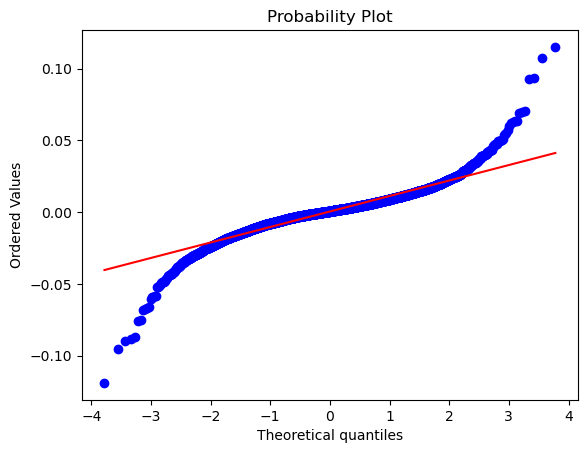

In [16]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(sp['DlyTotRet'], dist="norm", plot=plt)
plt.show()

In [ ]:
#Asse X → quantili teorici normali, Asse Y → quantili osservati

In [6]:
from scipy.stats import norm, chi2
import numpy as np

r = sp["DlyTotRet"]

mu = r.mean()
sigma = r.std()

k = 10

# Evitiamo -inf e +inf
quantiles = norm.ppf(np.linspace(0.001, 0.999, k+1), loc=mu, scale=sigma)

observed, _ = np.histogram(r, bins=quantiles)

expected = np.ones(k) * len(r) / k

chi_stat = np.sum((observed - expected)**2 / expected)

df = k - 1 - 2

p_value = 1 - chi2.cdf(chi_stat, df)

print("Chi-square statistic:", chi_stat)
print("Degrees of freedom:", df)
print("p-value:", p_value)

Chi-square statistic: 1184.711466485199
Degrees of freedom: 7
p-value: 0.0
